## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
import keras
import numpy.matlib
import mat73

from numpy import asarray
from scipy import stats, signal, io
from scipy.ndimage import median_filter as medfilt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from utils import tic, toc, hankel_matrix, scaler, legendre_polys, find_opt_lag
from models import linear_regression, VAE

%matplotlib widget

2024-03-18 23:06:41.176641: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-03-18 23:06:41.303897: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-03-18 23:06:41.303924: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2024-03-18 23:06:41.334014: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-18 23:06:41.975930: W tensorflow/stream_executor/pla

## Load and preprocess data

In [2]:
data_dir = '/data'
mask = io.loadmat(data_dir+'/brain_mask.mat')
mask = mask["newmask"]
mask.dtype = bool
mask_long = mask.reshape(16384,order='F')

In [3]:
s = 1

data_dict = mat73.loadmat(data_dir + '/' + str(s) + '_pupil.mat')
pupil = data_dict['pupil'].reshape(-1,1)
data_dict = mat73.loadmat(data_dir + '/' + str(s) + '_jrgeco.mat')
brain = data_dict['data'][:,mask_long]

# remove initial transient
pupil = pupil[800:,:]
brain = brain[800:,:]

pupil = medfilt(pupil,21)

Fs = 20
dt = 1/Fs
sos = signal.butter(1, [.01,.2],btype = 'bandpass', output = 'sos', fs = Fs)

pupil = signal.sosfiltfilt(sos, pupil, axis = 0)
brain = signal.sosfiltfilt(sos, brain, axis = 0)

## Analysis

In [4]:
## Set delay embedding parameters

delay = 1 # implement delay embedding? 0 or 1
nonlinear = 1 # use nonlinear mappings (VAE) (as opposed to linear regression) ? 0 or 1
Fs = 20 # sampling frequency
dt = 1/Fs
stackmax = 100 # Hankel row dimension (i.e., number of time shifts)
spacing = 3 # number of samples separating each row
r = 10 # number of modes of the Hankel matrix to keep (used for projection onto top r Legendre polynomials)
z_n = 4 # number of latent dimensions used for VAE
anneal_step = 1000 # determines rate at which KL loss is increased during training
beta = .1 # beta weight for KL loss in VAE training
num_epochs = 200 # number of training epochs

In [5]:
## Train-test split
xtrain, xtest, ytrain, ytest = train_test_split(pupil,brain,test_size=brain.shape[0]-6000,shuffle=False)

xtest = xtest[1000:,:] # enforce 50s (50/dt) gap to mitigate overlap between train and test
ytest = ytest[1000:,:]

In [6]:
## Adjust for pupil:brain lag

# Find lag
lag_range = 5 # range over which to look for optimal lag between pupil and brain cross-correlation (in seconds)
lag_range = int(lag_range/dt)
lag,_,_ = find_opt_lag(xtrain,np.mean(ytrain,axis=1),lag_range)

# Adjust
if lag:
    xtrain = xtrain[lag:,:]
    ytrain = ytrain[:-lag,:]
    
    xtest = xtest[lag:,:]
    ytest = ytest[:-lag,:]

In [7]:
## Time delay embedding    
if delay:
    polys = legendre_polys(r, stackmax)

    Hp_train = hankel_matrix(xtrain.T,stackmax,spacing)
    Hp_test = hankel_matrix(xtest.T,stackmax,spacing)

    xtrain = Hp_train.T@polys
    xtest = Hp_test.T@polys
    
else:
    xtrain = xtrain[spacing*(stackmax-1):,:]
    xtest = xtest[spacing*(stackmax-1):,:]

ytrain = ytrain[spacing*(stackmax-1):,:]
ytest = ytest[spacing*(stackmax-1):,:]

In [8]:
## Preprocessing
xtrain_sc, scale_x = scaler(xtrain)
ytrain_sc, scale_y = scaler(ytrain)

In [9]:
## Train model
if nonlinear:
    r_squared, model, encoder, decoder = VAE(xtrain_sc, ytrain_sc, latent_dim=z_n, beta=beta, num_epochs=num_epochs, anneal_step=anneal_step)
else:
    r_squared, model = linear_regression(xtrain_sc, ytrain_sc)

ytrain_hat_sc = model.predict(xtrain_sc)

r_squared

2024-03-18 23:06:52.740860: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2024-03-18 23:06:52.740889: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2024-03-18 23:06:52.740916: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (cbd0833098a6): /proc/driver/nvidia/version does not exist
2024-03-18 23:06:52.741127: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/200
6/6 [==============================] - 1s 27ms/step - loss: 0.0982 - reconstruction_loss: 0.0988 - kl_loss: 8.7037e-06 - kl_anneal: 2.8571e-04
Epoch 2/200
6/6 [==============================] - 0s 27ms/step - loss: 0.0918 - reconstruction_loss: 0.0904 - kl_loss: 3.0224e-05 - kl_anneal: 8.8571e-04
Epoch 3/200
6/6 [==============================] - 0s 26ms/step - loss: 0.0799 - reconstruction_loss: 0.0750 - kl_loss: 5.8349e-05 - kl_anneal: 0.0015
Epoch 4/200
6/6 [==============================] - 0s 25ms/step - loss: 0.0607 - reconstruction_loss: 0.0587 - kl_loss: 1.0122e-04 - kl_anneal: 0.0021
Epoch 5/200
6/6 [==============================] - 0s 26ms/step - loss: 0.0534 - reconstruction_loss: 0.0519 - kl_loss: 1.7297e-04 - kl_anneal: 0.0027
Epoch 6/200
6/6 [==============================] - 0s 26ms/step - loss: 0.0494 - reconstruction_loss: 0.0491 - kl_loss: 2.9285e-04 - kl_anneal: 0.0033
Epoch 7/200
6/6 [==============================] - 0s 26ms/step - loss: 0.0456 - recon

0.8002995837235951

In [10]:
## Test model
xtest_sc,_ = scaler(xtest, scale_x)
ytest_sc,_ = scaler(ytest, scale_y)
ytest = scale_y.inverse_transform(ytest_sc) # scaling/unscaling essentially corrects for mean offset

ytest_hat_sc = model.predict(xtest_sc)
ytest_hat = scale_y.inverse_transform(ytest_hat_sc)

r2_score(ytest, ytest_hat, multioutput='variance_weighted')

0.6289418496538163

## Visualize

In [11]:
## Project back to brain

data1 = ytest
data2 = ytest_hat

outmat1 = np.zeros((data1.shape[0],16384), dtype=np.single)
outmat1[:,mask_long] = StandardScaler(with_std=False).fit_transform(data1)
outmat1 = np.ma.masked_where(outmat1==0, outmat1)
outmat1 = outmat1.reshape(data1.shape[0],128,128,order='F')

outmat2 = np.zeros((data2.shape[0],16384), dtype=np.single)
outmat2[:,mask_long] = StandardScaler(with_std=False).fit_transform(data2)
outmat2 = np.ma.masked_where(outmat2==0, outmat2)
outmat2 = outmat2.reshape(data2.shape[0],128,128,order='F')

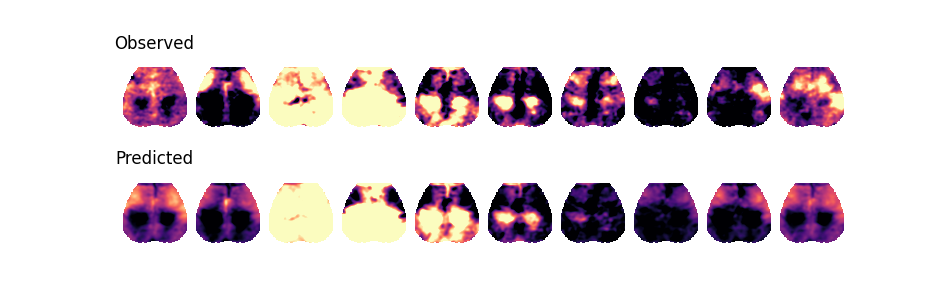

In [12]:
nframes = 10
step = 80
offset = 2179

fig, axes = plt.subplots(2,nframes,sharex='col',figsize=(9.42,3))

c1 = .005
c2 = c1

axes = axes.flatten()
for i, ax in enumerate(axes):
    
    if i<nframes:
        ax.imshow(outmat1[i*step + offset,:,:], vmin=-c1, vmax=c1, cmap = 'magma')
        
    else:
        ax.imshow(outmat2[(i-nframes)*step + offset,:,:], vmin=-c2, vmax=c2, cmap = 'magma')    

    ax.axis('off')

axes[0].set_title('Observed')
axes[nframes].set_title('Predicted')
    
plt.subplots_adjust(wspace=0, hspace=0)

plt.show()
